<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Deep_Fake_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
#Importando bibliotecas
import os
if not os.path.exists('Faceswap-Deepfake-Pytorch'):
    !wget -q https://raw.githubusercontent.com/sizhky/deep-fake-util/main/random_warp.py
    !wget -q https://huggingface.co/datasets/sizhkhy/mcvp-datasets/resolve/main/person_images.zip
    !unzip -q person_images.zip
!pip install -q torch_snippets torch_summary
from torch_snippets import *
from random_warp import get_training_data
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml') #carrega os dados

[person_images.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of person_images.zip or
        person_images.zip.zip, and cannot find person_images.zip.ZIP, period.


#### Esse código inteiro estava dando erro, troquei o link do Dropbox pois o link foi desativado e não estava funcionando como devia

In [47]:
def crop_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #tons de cinza na imagem
    faces = face_cascade.detectMultiScale(gray, 1.3, 5) #busca as imagens de rosto
    if(len(faces) > 0):
        for (x,y,w,h) in faces:
            img2 = img[y:(y+h),x:(x+w),:] #retira da imagem apenas o rosto
        img2 = cv2.resize(img2,(256,256))
        return img2, True
    else:
        return img, False

In [49]:
!mkdir -p cropped_faces_personA
!mkdir -p cropped_faces_personB

#função de recorte de todas as imagens
def crop_imagens(folder):
  imagens = Glob(folder+'/*.jpg')
  for i in range(len(imagens)):
    img = read(imagens[i],1)
    img2, face_detected = crop_face(img)
    if(face_detected==False):
      continue
    else:
      #salva as imagens recortadas em pastas separadas
       cv2.imwrite('cropped_faces_'+folder+'/'+str(i)+'.jpg',cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))
crop_imagens('personA')
crop_imagens('personB')

In [50]:
class ImageDataset(Dataset):
    def __init__(self, items_A, items_B):
        self.items_A = np.concatenate([read(f,1)[None] for f in items_A])/255.
        self.items_B = np.concatenate([read(f,1)[None] for f in items_B])/255.
        self.items_A += self.items_B.mean(axis=(0, 1, 2)) - self.items_A.mean(axis=(0, 1, 2))

    def __len__(self):
        return min(len(self.items_A), len(self.items_B)) #menor conjunto de imagens
    def __getitem__(self, ix):
        a, b = choose(self.items_A), choose(self.items_B)
        return a, b

    def collate_fn(self, batch): # dados de treinamento
        imsA, imsB = list(zip(*batch))
        imsA, targetA = get_training_data(imsA, len(imsA))
        imsB, targetB = get_training_data(imsB, len(imsB))
        imsA, imsB, targetA, targetB = [torch.Tensor(i).permute(0,3,1,2).to(device) for i in [imsA, imsB, targetA, targetB]]
        return imsA, imsB, targetA, targetB

a = ImageDataset(Glob('cropped_faces_personA'), Glob('cropped_faces_personB')) #cria o dataset
x = DataLoader(a, batch_size=32, collate_fn=a.collate_fn) #cria um dataloader com o batch

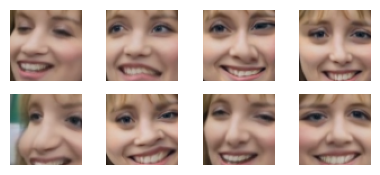

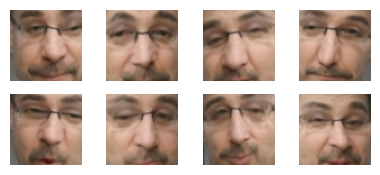

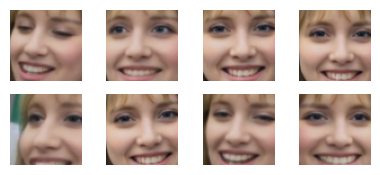

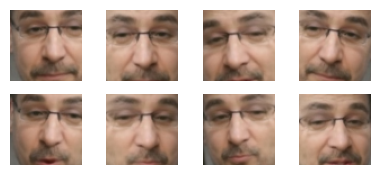

In [63]:
#função do inspect estava dando erro
for i in [imsA, imsB, targetA, targetB]:
  subplots(i[:8], nc=4, sz=(4,2))

In [60]:
def _ConvLayer(input_features, output_features):
    return nn.Sequential(
        nn.Conv2d(input_features, output_features, kernel_size=5, stride=2, padding=2),
        nn.LeakyReLU(0.1, inplace=True)
    )

def _UpScale(input_features, output_features): # aumenta a resolução da imagem
    return nn.Sequential(
        nn.ConvTranspose2d(input_features, output_features, kernel_size=2, stride=2, padding=0),
        nn.LeakyReLU(0.1, inplace=True)
    )

class Reshape(nn.Module): # pega a imagem e a remodela
    def forward(self, input):
        output = input.view(-1, 1024, 4, 4)
        return output

In [61]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            _ConvLayer(3, 128),
            _ConvLayer(128, 256),
            _ConvLayer(256, 512),
            _ConvLayer(512, 1024),
            nn.Flatten(),
            nn.Linear(1024 * 4 * 4, 1024),
            nn.Linear(1024, 1024 * 4 * 4), #camada conectada
            Reshape(),
            _UpScale(1024, 512),
        )

        self.decoder_A = nn.Sequential(
            _UpScale(512, 256),
            _UpScale(256, 128),
            _UpScale(128, 64), # aumenta a imagem
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

        self.decoder_B = nn.Sequential(
            _UpScale(512, 256),
            _UpScale(256, 128),
            _UpScale(128, 64), #aumenta a imagem
        nn.Sigmoid(),
    )

    def forward(self, x, select='A'): # fluxo do modelo
        if select == 'A':
            out = self.encoder(x)
            out = self.decoder_A(out)
        else:
            out = self.encoder(x)
            out = self.decoder_B(out)
        return out